# Bell States: Construction, Simulation, and Measurement in Qiskit

## 1. Introduction

The **Bell states** (also called *EPR pairs*, after Einstein, Podolsky, and Rosen) are the four maximally entangled two-qubit quantum states. They form an orthonormal basis for the two-qubit Hilbert space — the **Bell basis** — and are the canonical example used to demonstrate entanglement, violate local-hidden-variable inequalities (Bell/CHSH inequalities), and underpin protocols such as quantum teleportation, superdense coding, and entanglement swapping [1, 2].

This notebook builds each of the four Bell states from scratch in Qiskit, inspects their exact statevectors symbolically, and verifies the expected measurement statistics via simulation. We first walk through the canonical state $|\Phi^+\rangle$ in full detail, then repeat the construction for the remaining three states, and finally collect everything into a single reusable, parameterized circuit generator for comparative analysis.

**References for this section:** [1] Wikipedia, *Bell state* — https://en.wikipedia.org/wiki/Bell_state; [2] M. A. Nielsen and I. L. Chuang, *Quantum Computation and Quantum Information*, Cambridge University Press (2010), §1.3.6.


## 2. The Four Bell States

Starting from the computational basis $\{|00\rangle, |01\rangle, |10\rangle, |11\rangle\}$, the Bell basis is obtained by applying a Hadamard gate to the first qubit followed by a CNOT gate (control = qubit 0, target = qubit 1). Applying this **entangling core** ($H_0$ then $\mathrm{CX}_{0\to1}$) to each of the four computational basis states produces the four Bell states [1]:

| Bell State | Circuit (state prep $\to$ entangling core) | Mathematical Expression |
|---|---|---|
| $\lvert\Phi^+\rangle$ | `qc.h(0)`, `qc.cx(0, 1)` | $\dfrac{1}{\sqrt{2}}\big(\lvert00\rangle+\lvert11\rangle\big)$ |
| $\lvert\Phi^-\rangle$ | `qc.x(0)`, `qc.h(0)`, `qc.cx(0, 1)` | $\dfrac{1}{\sqrt{2}}\big(\lvert00\rangle-\lvert11\rangle\big)$ |
| $\lvert\Psi^+\rangle$ | `qc.x(1)`, `qc.h(0)`, `qc.cx(0, 1)` | $\dfrac{1}{\sqrt{2}}\big(\lvert01\rangle+\lvert10\rangle\big)$ |
| $\lvert\Psi^-\rangle$ | `qc.x(1)`, `qc.x(0)`, `qc.h(0)`, `qc.cx(0, 1)` | $\dfrac{1}{\sqrt{2}}\big(\lvert01\rangle-\lvert10\rangle\big)$ |

**Why this works.** Starting from $|00\rangle$, `h(0)` prepares $\frac{1}{\sqrt{2}}(|00\rangle + |10\rangle)$, and `cx(0,1)` flips qubit 1 whenever qubit 0 is $|1\rangle$, giving $\frac{1}{\sqrt{2}}(|00\rangle + |11\rangle) = |\Phi^+\rangle$. Since $X$ on qubit 0 flips the *relative sign* produced by the Hadamard (via the $Z$-basis phase kickback path through the state $|1\rangle \to H \to \frac{1}{\sqrt2}(|0\rangle-|1\rangle)$), and $X$ on qubit 1 flips which computational-basis pair ($00/11$ vs. $01/10$) the entangler acts on, the two single-qubit $X$ gates applied *before* the entangling core select which of the four Bell states is produced. Equivalently, the four Bell states are related by local Pauli operations: $|\Phi^-\rangle = (Z\otimes I)|\Phi^+\rangle$, $|\Psi^+\rangle = (X\otimes I)|\Phi^+\rangle$, $|\Psi^-\rangle = (Y\otimes I)|\Phi^+\rangle$ (up to global phase) [1, 2].

Each of these states is **maximally entangled**: the reduced density matrix of either qubit, obtained by tracing out the other, is the maximally mixed state $I/2$, meaning neither qubit carries any information on its own — the information is stored entirely in the correlations between the two qubits [2].


## 3. Setup

We use Qiskit's `QuantumCircuit` to build the circuits, `Statevector` to inspect the exact (noise-free) quantum state symbolically, and `AerSimulator` to obtain measurement statistics over a finite number of shots.


In [1]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

## 4. State $|\Phi^+\rangle$ — Step-by-Step Walkthrough

We start with the fully worked example of the canonical Bell state
$$|\Phi^+\rangle = \frac{1}{\sqrt{2}}\big(|00\rangle + |11\rangle\big),$$
building the circuit gate by gate so that the intermediate state is visible at every step.

### 4.1 Initial Circuit

Both qubits start in $|0\rangle$, so the initial circuit has no gates.


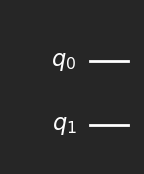

In [2]:
# Initial quantum circuit of 2 qubits
qc = QuantumCircuit(2)

# Plotting initial quantum circuit
qc.draw(output='mpl', style='iqp-dark')

In [3]:
# Initial state
qc_initial_state = Statevector(qc)
qc_initial_state.draw('latex')

<IPython.core.display.Latex object>

As expected, the initial state is simply $|00\rangle$ — a product state with no entanglement.

### 4.2 Applying the Entangling Core

We now apply the Hadamard gate to qubit 0, followed by a CNOT with qubit 0 as control and qubit 1 as target. This is the entangling core shared by all four Bell states.


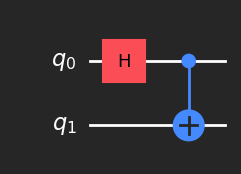

In [4]:
# Creating Bell State: |\Phi^+> = 1/\sqrt{2}(|00> + |11>)
qc_phi_plus = qc.copy()

# Hadamard Gate
qc_phi_plus.h(0)

# CNOT Gate
qc_phi_plus.cx(0, 1)

# Plotting qc_phi_plus
qc_phi_plus.draw(output='mpl', style='iqp-dark')

In [5]:
# State after gates
phi_plus_state = Statevector(qc_phi_plus)
phi_plus_state.draw('latex')

<IPython.core.display.Latex object>

The statevector confirms $|\Phi^+\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$ exactly, with equal amplitudes $\frac{1}{\sqrt{2}} \approx 0.7071$ on $|00\rangle$ and $|11\rangle$, and zero amplitude on $|01\rangle$ and $|10\rangle$. This confirms the circuit produces the target Bell state before any measurement is taken.

### 4.3 Measurement and Simulation

Adding measurements collapses the superposition. Because $|\Phi^+\rangle$ has support only on $|00\rangle$ and $|11\rangle$, we expect the two qubits to always be measured in the *same* state — either both $0$ or both $1$ — with equal probability, and never $01$ or $10$.


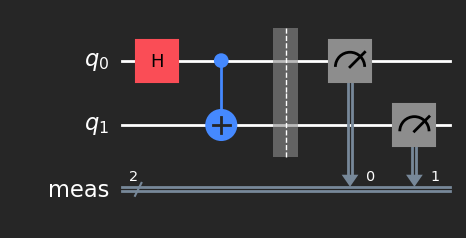

In [6]:
qc_phi_plus.measure_all()
qc_phi_plus.draw(output='mpl', style='iqp-dark')

In [7]:
sim = AerSimulator()
counts_aer_phi_plus = sim.run(qc_phi_plus, shots=1024).result().get_counts()
print(f'AerSimulator counts (1024 shots): {counts_aer_phi_plus}')

AerSimulator counts (1024 shots): {'11': 498, '00': 526}


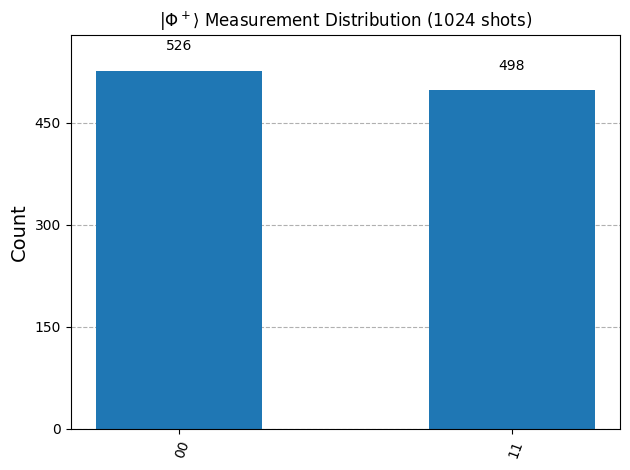

In [8]:
plot_histogram(counts_aer_phi_plus, title=r'$|\Phi^+\rangle$ Measurement Distribution (1024 shots)')

As predicted, only the `00` and `11` outcomes appear, each with a frequency close to 50% (subject to the usual $O(1/\sqrt{N})$ shot-noise fluctuation for $N=1024$ shots). This is the defining signature of $|\Phi^+\rangle$: perfectly correlated computational-basis outcomes with no bias between the two possibilities.


## 5. State $|\Phi^-\rangle$ — Step-by-Step Walkthrough

Next we construct
$$|\Phi^-\rangle = \frac{1}{\sqrt{2}}\big(|00\rangle - |11\rangle\big),$$
which differs from $|\Phi^+\rangle$ only by a **relative phase** on the $|11\rangle$ component. Per the table in Section 2, this is prepared by applying `x(0)` *before* the entangling core, which routes the state through the $H|1\rangle = \frac{1}{\sqrt2}(|0\rangle - |1\rangle)$ branch and imprints the minus sign.


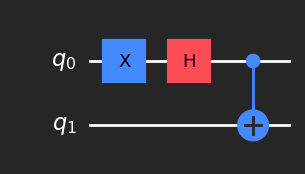

In [9]:
qc_phi_minus = QuantumCircuit(2)

# Pre-rotation: flip qubit 0 before entangling
qc_phi_minus.x(0)

# Entangling core
qc_phi_minus.h(0)
qc_phi_minus.cx(0, 1)

qc_phi_minus.draw(output='mpl', style='iqp-dark')

In [10]:
phi_minus_state = Statevector(qc_phi_minus)
phi_minus_state.draw('latex')

<IPython.core.display.Latex object>

The statevector shows amplitudes $+\frac{1}{\sqrt{2}}$ on $|00\rangle$ and $-\frac{1}{\sqrt{2}}$ on $|11\rangle$, confirming the relative phase flip relative to $|\Phi^+\rangle$. Note that this phase is invisible to a computational-basis measurement — it only becomes observable when qubits are measured in a rotated basis (e.g. the $X$ basis) or via an interference experiment such as a Bell/CHSH test.

### 5.1 Measurement and Simulation


AerSimulator counts (1024 shots): {'11': 503, '00': 521}


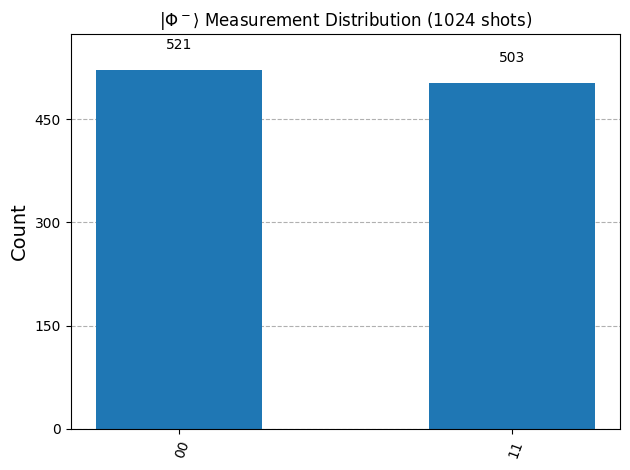

In [11]:
qc_phi_minus_meas = qc_phi_minus.copy()
qc_phi_minus_meas.measure_all()

counts_phi_minus = sim.run(qc_phi_minus_meas, shots=1024).result().get_counts()
print(f'AerSimulator counts (1024 shots): {counts_phi_minus}')
plot_histogram(counts_phi_minus, title=r'$|\Phi^-\rangle$ Measurement Distribution (1024 shots)')

As expected, the computational-basis measurement statistics for $|\Phi^-\rangle$ are indistinguishable from $|\Phi^+\rangle$: only `00` and `11` appear, roughly 50/50. This illustrates an important point — measurement counts alone cannot distinguish $|\Phi^+\rangle$ from $|\Phi^-\rangle$; the exact statevector (Section 5, above) is what reveals the relative phase.


## 6. State $|\Psi^+\rangle$ — Step-by-Step Walkthrough

Now we construct
$$|\Psi^+\rangle = \frac{1}{\sqrt{2}}\big(|01\rangle + |10\rangle\big),$$
which entangles the *opposite* computational-basis pairs to $|\Phi^+\rangle$. This is prepared with `x(1)` before the entangling core, which flips qubit 1 so that the CNOT correlates the qubits into the odd-parity subspace $\{|01\rangle, |10\rangle\}$ instead of the even-parity subspace $\{|00\rangle, |11\rangle\}$.


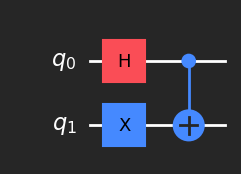

In [12]:
qc_psi_plus = QuantumCircuit(2)

# Pre-rotation: flip qubit 1 before entangling
qc_psi_plus.x(1)

# Entangling core
qc_psi_plus.h(0)
qc_psi_plus.cx(0, 1)

qc_psi_plus.draw(output='mpl', style='iqp-dark')

In [13]:
psi_plus_state = Statevector(qc_psi_plus)
psi_plus_state.draw('latex')

<IPython.core.display.Latex object>

The statevector confirms equal-magnitude amplitudes on $|01\rangle$ and $|10\rangle$ only. This is the **anti-correlated** Bell state: the two qubits will always be measured in *opposite* states.

### 6.1 Measurement and Simulation


AerSimulator counts (1024 shots): {'10': 529, '01': 495}


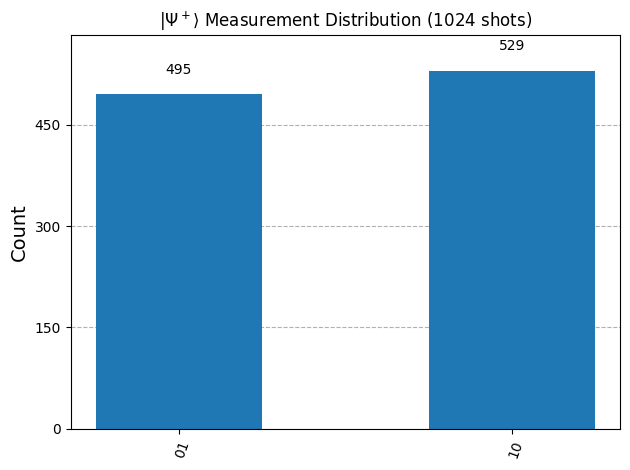

In [14]:
qc_psi_plus_meas = qc_psi_plus.copy()
qc_psi_plus_meas.measure_all()

counts_psi_plus = sim.run(qc_psi_plus_meas, shots=1024).result().get_counts()
print(f'AerSimulator counts (1024 shots): {counts_psi_plus}')
plot_histogram(counts_psi_plus, title=r'$|\Psi^+\rangle$ Measurement Distribution (1024 shots)')

As expected, only `01` and `10` appear (each near 50%), and `00`/`11` never occur. This confirms the anti-correlation structure of $|\Psi^+\rangle$: measuring one qubit deterministically reveals the *opposite* outcome for the other, in the computational basis.


## 7. State $|\Psi^-\rangle$ — Step-by-Step Walkthrough

Finally, we construct the **singlet state**
$$|\Psi^-\rangle = \frac{1}{\sqrt{2}}\big(|01\rangle - |10\rangle\big),$$
the unique Bell state that is antisymmetric under qubit exchange, and the only one that is *rotationally invariant* — it looks the same in any shared measurement basis for the two qubits, which is why it plays a special role in the original EPR/Bohm formulation and in entanglement-swapping protocols [2]. It combines both pre-rotations: `x(1)` selects the odd-parity subspace, and `x(0)` (applied before the Hadamard) imprints the relative minus sign, exactly as in the $|\Phi^-\rangle$ construction.


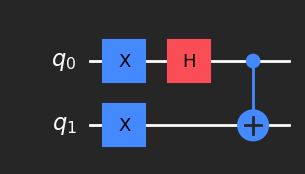

In [15]:
qc_psi_minus = QuantumCircuit(2)

# Pre-rotation: flip both qubits before entangling
qc_psi_minus.x(1)
qc_psi_minus.x(0)

# Entangling core
qc_psi_minus.h(0)
qc_psi_minus.cx(0, 1)

qc_psi_minus.draw(output='mpl', style='iqp-dark')

In [16]:
psi_minus_state = Statevector(qc_psi_minus)
psi_minus_state.draw('latex')

<IPython.core.display.Latex object>

The statevector shows amplitude $+\frac{1}{\sqrt{2}}$ on $|01\rangle$ and $-\frac{1}{\sqrt{2}}$ on $|10\rangle$, confirming both the odd-parity structure and the relative phase, i.e. the singlet state.

### 7.1 Measurement and Simulation


AerSimulator counts (1024 shots): {'10': 502, '01': 522}


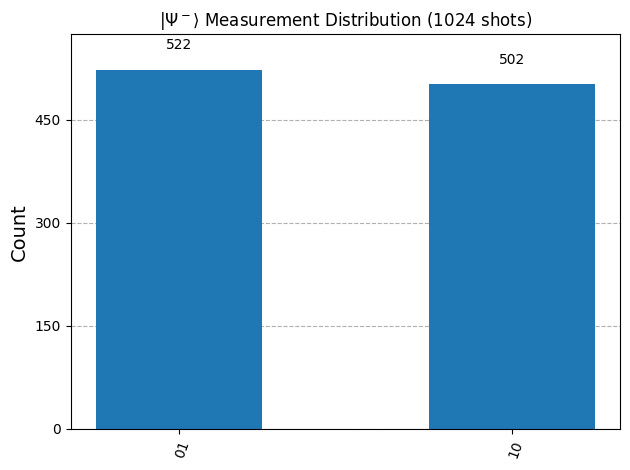

In [17]:
qc_psi_minus_meas = qc_psi_minus.copy()
qc_psi_minus_meas.measure_all()

counts_psi_minus = sim.run(qc_psi_minus_meas, shots=1024).result().get_counts()
print(f'AerSimulator counts (1024 shots): {counts_psi_minus}')
plot_histogram(counts_psi_minus, title=r'$|\Psi^-\rangle$ Measurement Distribution (1024 shots)')

As with $|\Psi^+\rangle$, the computational-basis measurement statistics show only `01` and `10`, roughly 50/50 — again indistinguishable from $|\Psi^+\rangle$ at the level of raw counts, with the relative phase only visible in the exact statevector or in a rotated-basis measurement.


## 8. A General, Reusable Bell-State Generator

Having built each state by hand, we now consolidate the construction logic into a single parameterized function. This matches the circuit table in Section 2 directly: the `state_type` argument selects which pre-rotation(s) — if any — are applied before the shared entangling core (`h(0)`, `cx(0, 1)`).


In [18]:
def create_bell_state(state_type: str) -> QuantumCircuit:
    '''
    Creates a 2-qubit QuantumCircuit for a specified Bell state.

    Bell States:
      'phi_plus'  : (|00> + |11>) / sqrt(2)
      'phi_minus' : (|00> - |11>) / sqrt(2)
      'psi_plus'  : (|01> + |10>) / sqrt(2)
      'psi_minus' : (|01> - |10>) / sqrt(2)
    '''
    qc = QuantumCircuit(2, name=f"Bell_{state_type}")

    # State preparation initializations
    if state_type == 'phi_plus':
        pass  # Starts at |00>
    elif state_type == 'phi_minus':
        qc.x(0)  # Starts at |01> -> transforms to |00> - |11>
    elif state_type == 'psi_plus':
        qc.x(1)  # Starts at |10> -> transforms to |01> + |10>
    elif state_type == 'psi_minus':
        qc.x(0)
        qc.x(1)  # Starts at |11> -> transforms to |01> - |10>
    else:
        raise ValueError(
            "Invalid state_type. Choose: 'phi_plus', 'phi_minus', 'psi_plus', 'psi_minus'"
        )

    # Entangling Core: H on qubit 0, CNOT with control=0, target=1
    qc.h(0)
    qc.cx(0, 1)

    return qc

We can sanity-check this generator against the four circuits built by hand in Sections 4–7 by comparing statevectors.


In [19]:
bell_types = ['phi_plus', 'phi_minus', 'psi_plus', 'psi_minus']
manual_states = {
    'phi_plus': phi_plus_state,
    'phi_minus': phi_minus_state,
    'psi_plus': psi_plus_state,
    'psi_minus': psi_minus_state,
}

for b_type in bell_types:
    generated_state = Statevector(create_bell_state(b_type))
    match = generated_state.equiv(manual_states[b_type])
    print(f"{b_type:>10}: generator matches manual construction -> {match}")

  phi_plus: generator matches manual construction -> True
 phi_minus: generator matches manual construction -> True
  psi_plus: generator matches manual construction -> True
 psi_minus: generator matches manual construction -> True


All four match (up to global phase, which `Statevector.equiv` correctly ignores), confirming that the general-purpose function reproduces exactly the states derived by hand above.


## 9. Comparative Simulation of All Four Bell States

With the generator function validated, we can now build, simulate, and compare all four Bell states in a single compact pipeline: construct each circuit, record its exact theoretical statevector, append measurements, run on `AerSimulator`, and finally plot all four measurement distributions side by side.


In [20]:
circuits = {}
statevectors = {}

for b_type in bell_types:
    qc = create_bell_state(b_type)
    circuits[b_type] = qc

    # Compute exact theoretical statevector before adding measurements
    statevectors[b_type] = Statevector(qc)

# Display calculated Statevectors
for b_type, sv in statevectors.items():
    print(f"--- Statevector for {b_type} ---")
    print(sv.data)

--- Statevector for phi_plus ---
[0.70710678+0.j 0.        +0.j 0.        +0.j 0.70710678+0.j]
--- Statevector for phi_minus ---
[ 0.70710678+0.j  0.        +0.j  0.        +0.j -0.70710678+0.j]
--- Statevector for psi_plus ---
[0.        +0.j 0.70710678+0.j 0.70710678+0.j 0.        +0.j]
--- Statevector for psi_minus ---
[ 0.        +0.j -0.70710678+0.j  0.70710678+0.j  0.        +0.j]


In [21]:
sim_circuits = {}
for b_type, qc in circuits.items():
    meas_qc = qc.copy()
    meas_qc.measure_all()
    sim_circuits[b_type] = meas_qc

simulator = AerSimulator()
counts_dict = {}

# Execute simulations
for b_type, qc in sim_circuits.items():
    job = simulator.run(qc, shots=1024)
    counts_dict[b_type] = job.result().get_counts()

counts_dict

{'phi_plus': {'00': 530, '11': 494},
 'phi_minus': {'00': 496, '11': 528},
 'psi_plus': {'10': 524, '01': 500},
 'psi_minus': {'10': 495, '01': 529}}

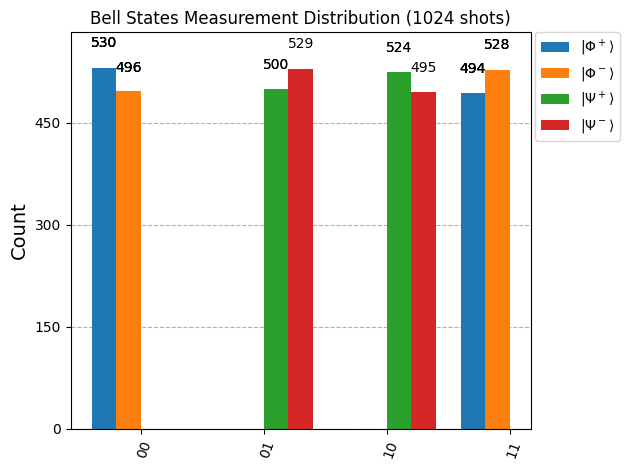

In [22]:
plot_histogram(
    [counts_dict['phi_plus'], counts_dict['phi_minus'], counts_dict['psi_plus'], counts_dict['psi_minus']],
    legend=[r'$|\Phi^+\rangle$', r'$|\Phi^-\rangle$', r'$|\Psi^+\rangle$', r'$|\Psi^-\rangle$'],
    title="Bell States Measurement Distribution (1024 shots)"
)

The comparative histogram makes the key experimental signature clear at a glance: $|\Phi^+\rangle$ and $|\Phi^-\rangle$ both populate only the **even-parity** outcomes (`00`, `11`), while $|\Psi^+\rangle$ and $|\Psi^-\rangle$ both populate only the **odd-parity** outcomes (`01`, `10`). Within each pair, the "$+$" and "$-$" states are statistically identical in the computational basis — the relative phase distinguishing them is not observable from $Z$-basis counts alone, as already seen in Sections 5 and 7.


## 10. Verifying Entanglement and Distinguishing the Phase

Since $Z$-basis measurement statistics cannot distinguish $|\Phi^+\rangle$ from $|\Phi^-\rangle$ (nor $|\Psi^+\rangle$ from $|\Psi^-\rangle$), we use two complementary checks to confirm both the entanglement structure and the relative phase:

1. **State fidelity** against the exact theoretical Bell states, using `Statevector.equiv` / inner product overlap — this is the strongest check, but requires access to the exact statevector (only available in ideal simulation, not on real hardware).
2. **A basis-change measurement**: applying a Hadamard to *both* qubits before measuring converts the relative-phase information into distinguishable computational-basis populations, since $H\otimes H$ maps $|\Phi^+\rangle \leftrightarrow$ even-parity-in-$X$-basis outcomes and $|\Phi^-\rangle \leftrightarrow$ odd-parity outcomes (and analogously for the $\Psi$ pair) [2].

We demonstrate the second approach below for the $|\Phi^+\rangle$ / $|\Phi^-\rangle$ pair.


|Phi+> in X basis: {'11': 531, '00': 493}
|Phi-> in X basis: {'10': 511, '01': 513}


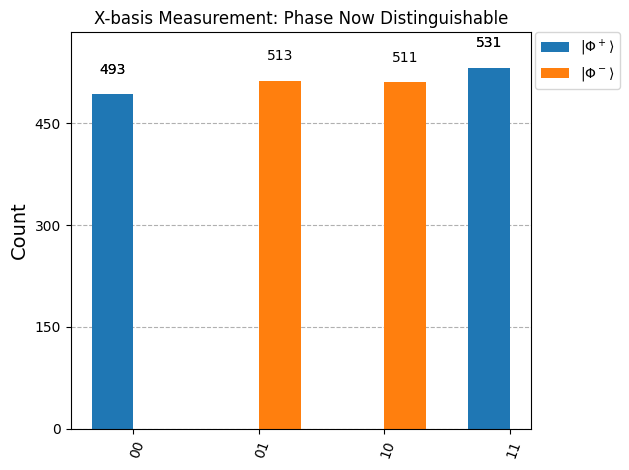

In [23]:
def measure_in_x_basis(qc: QuantumCircuit) -> QuantumCircuit:
    '''Rotates both qubits into the X basis and measures.'''
    rotated = qc.copy()
    rotated.h(0)
    rotated.h(1)
    rotated.measure_all()
    return rotated

phi_plus_x = measure_in_x_basis(circuits['phi_plus'])
phi_minus_x = measure_in_x_basis(circuits['phi_minus'])

counts_phi_plus_x = simulator.run(phi_plus_x, shots=1024).result().get_counts()
counts_phi_minus_x = simulator.run(phi_minus_x, shots=1024).result().get_counts()

print(f"|Phi+> in X basis: {counts_phi_plus_x}")
print(f"|Phi-> in X basis: {counts_phi_minus_x}")

plot_histogram(
    [counts_phi_plus_x, counts_phi_minus_x],
    legend=[r'$|\Phi^+\rangle$', r'$|\Phi^-\rangle$'],
    title="X-basis Measurement: Phase Now Distinguishable"
)

In the $X$ basis, $|\Phi^+\rangle$ now shows only the *even*-parity outcomes (`00`, `11`), while $|\Phi^-\rangle$ shows only the *odd*-parity outcomes (`01`, `10`) — the two states are now clearly distinguished, confirming that the difference between them is exactly the relative phase predicted analytically in Section 5. This basis-rotation trick is the operational essence of Bell-state discrimination circuits used in quantum teleportation and superdense coding [1, 2].


## 11. Conclusion and Further Reading

This notebook constructed all four Bell states from first principles — first via an explicit, gate-by-gate walkthrough for each state individually, then via a single reusable generator function — and verified their theoretical statevectors and measurement statistics using Qiskit's `Statevector` and `AerSimulator`. Key takeaways:

- All four Bell states are produced by the same two-gate entangling core (`h(0)`, `cx(0, 1)`), preceded by state-dependent single-qubit $X$ gates that select the target state.
- Computational-basis measurement alone distinguishes the *parity* of the state ($\Phi$ vs. $\Psi$ pairs) but **not** the relative phase ($+$ vs. $-$ within a pair); a basis rotation (e.g. Hadamard before measurement) is required to reveal the phase.
- All four states are maximally entangled and related to one another by local Pauli operations, consistent with their role as a basis for the two-qubit Hilbert space.

**Possible extensions:**
- Run these circuits on real IBM Quantum hardware (or a noisy `FakeBrisbane`-style simulator) and compare the resulting fidelities to the ideal statistics above.
- Implement a full Bell-state discrimination circuit (the inverse of the entangling core) to map each Bell state back to a unique computational-basis outcome, as used in quantum teleportation.
- Extend the CHSH inequality experiment on top of $|\Phi^+\rangle$ to quantitatively demonstrate violation of local realism.

### References

[1] Wikipedia contributors, "Bell state," *Wikipedia, The Free Encyclopedia*. https://en.wikipedia.org/wiki/Bell_state (accessed 2026).

[2] M. A. Nielsen and I. L. Chuang, *Quantum Computation and Quantum Information*, 10th Anniversary Edition, Cambridge University Press, 2010, §1.3.6 and §2.3.

[3] J. S. Bell, "On the Einstein Podolsky Rosen Paradox," *Physics Physique Fizika*, vol. 1, no. 3, pp. 195–200, 1964.

[4] A. Einstein, B. Podolsky, and N. Rosen, "Can Quantum-Mechanical Description of Physical Reality Be Considered Complete?," *Physical Review*, vol. 47, pp. 777–780, 1935.

[5] Qiskit Documentation — `qiskit.quantum_info.Statevector`, `qiskit_aer.AerSimulator`. https://docs.quantum.ibm.com
